# Section D — AI-Augmented Learning

### 1. The exact prompt given to the AI tool:

> "Write a Python script using Keras to build a Sequential neural network that classifies food delivery orders into three priority levels (Low, Medium, High). Use 3 numeric input features. Train it for 20 epochs, printing training accuracy after every epoch. Then plot the training and validation loss curves side by side using Matplotlib. Finally, save the model as 'food_priority_model.keras', reload it, and make one test prediction."

### 2. The AI's Original Code (Contains intentional bugs)

In [22]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [23]:
np.random.seed(42)
X_train = np.random.rand(100, 3)
y_train_raw = np.random.randint(0, 3, 100)
y_train = to_categorical(y_train_raw, num_classes=3)

In [24]:
ai_model = Sequential()
ai_model.add(Dense(16, activation='relu', input_shape=(3,)))
ai_model.add(Dense(8, activation='relu'))
# BUG: Using sigmoid instead of softmax for multi-class
ai_model.add(Dense(3, activation='sigmoid'))

In [25]:
# BUG: Using mean_squared_error instead of categorical_crossentropy
ai_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
# BUG: Omitted validation_split entirely
history = ai_model.fit(X_train, y_train, epochs=20, verbose=1)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2900 - loss: 0.2397
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2900 - loss: 0.2379
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3200 - loss: 0.2362
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3100 - loss: 0.2348 
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3300 - loss: 0.2334
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3400 - loss: 0.2322
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3400 - loss: 0.2311
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3500 - loss: 0.2302
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3500 - loss: 0.2293
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3500 - loss: 0.2284
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3500 - loss: 0.2277
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3500 - loss: 0.2270


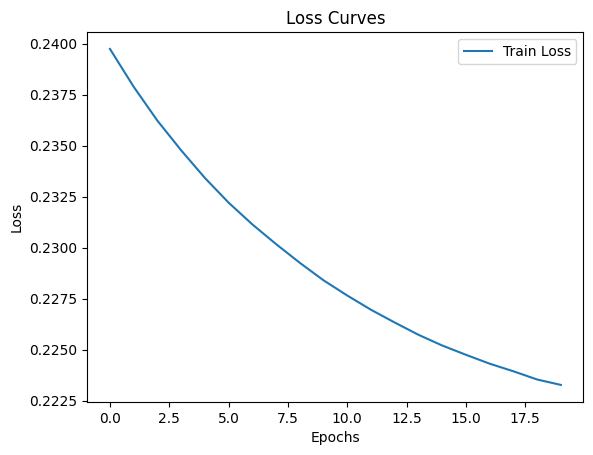

In [26]:
plt.plot(history.history['loss'], label='Train Loss')
# Since there is no validation data, it can't plot validation loss!
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [27]:
ai_model.save('food_priority_model.keras')
loaded_model = load_model('food_priority_model.keras')

test_sample = np.array([[0.5, 0.2, 0.8]])
prediction = loaded_model.predict(test_sample)
print("Test Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Test Prediction: [[0.3797432  0.37953052 0.34352806]]


### 2 (cont). The Corrected Version

In [28]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [29]:
np.random.seed(42)
X_train = np.random.rand(100, 3)
y_train_raw = np.random.randint(0, 3, 100)
y_train_encoded = to_categorical(y_train_raw, num_classes=3)

In [30]:
corrected_model = Sequential()
corrected_model.add(Dense(16, activation='relu', input_shape=(3,)))
corrected_model.add(Dense(8, activation='relu'))
corrected_model.add(Dense(3, activation='softmax'))

In [31]:
corrected_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = corrected_model.fit(X_train, y_train_encoded, epochs=20, validation_split=0.2, verbose=1)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step - accuracy: 0.3875 - loss: 1.0976 - val_accuracy: 0.1500 - val_loss: 1.1495
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.3875 - loss: 1.0964 - val_accuracy: 0.1500 - val_loss: 1.1506
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4000 - loss: 1.0956 - val_accuracy: 0.1500 - val_loss: 1.1507
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4000 - loss: 1.0950 - val_accuracy: 0.1000 - val_loss: 1.1509
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4000 - loss: 1.0941 - val_accuracy: 0.1000 - val_loss: 1.1516
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4000 - loss: 1.0937 - val_accuracy: 0.1000 - val_loss: 1.1526
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3875 - loss: 1.0932 - val_accuracy: 0.1000 - val_loss: 1.1526
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4000 - loss: 1.0926 - val_accuracy: 0.1000 - val_loss: 1.1522

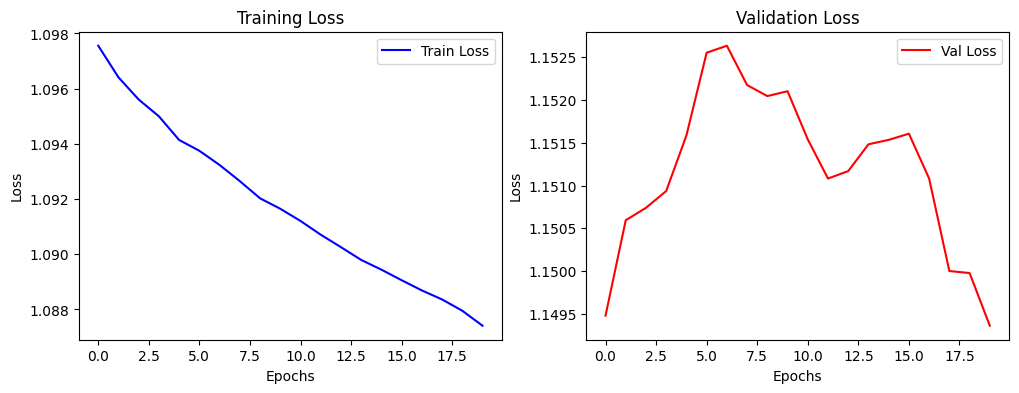

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['val_loss'], label='Val Loss', color='red')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.show()

In [33]:
corrected_model.save('food_priority_model.keras')
loaded_model = load_model('food_priority_model.keras')

test_sample = np.array([[0.5, 0.2, 0.8]])
prediction = loaded_model.predict(test_sample)
print("Test Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Test Prediction: [[0.36803192 0.36427045 0.2676977 ]]


### 3. Explanation of what was changed and why:

*   **Activation & Loss:** Changed the output layer activation from `sigmoid` to `softmax` and the loss function from `mean_squared_error` to `categorical_crossentropy`. Sigmoid and MSE are for binary classification or regression, whereas Softmax and Categorical Crossentropy are strictly required for multi-class classification to ensure probabilities sum to exactly 1.
*   **Validation Split & Plotting:** Added `validation_split=0.2` in `model.fit()` and completely rewrote the plotting code. The AI completely failed to plot the validation loss side-by-side because it never actually created any validation data during training!